In [ ]:
## corregido

from igraph import Graph
from igraph.clustering import VertexClustering
import random
import leidenalg


# Lista de grafos G1 a G10
grafos = [G1, G2, G3, G4, G5, G6, G7, G8, G9, G10]

# Semilla para reproducibilidad
semilla = 123

# Almacenar resultados para cada grafo y combinación

# Estructuras para almacenar resultados
resultados_modularidad = {f"G{i+1}": [] for i in range(len(grafos))}
tiempos_ejecucion = {f"G{i+1}": [] for i in range(len(grafos))}
resultados_excel = []  # Lista para almacenar los datos en formato tabular
ganamos=0
# Proceso para cada grafo
for idx, G in enumerate(grafos):
    resultados_grafo = []
    A = nx.to_numpy_array(G, dtype=float, weight="weight")

# Calcular A^2 y A^3
    A2 = np.linalg.matrix_power(A, 2)
    A3 = np.linalg.matrix_power(A, 3)
    # Recorremos de 0 a 100 para ajustar el peso de las aristas
    for i in range(101):  # De 0 a 100 recorremos alfa      
        for j in range(101) #de 0 a 100 recorremos beta
            combinada = 
        # Actualizamos los pesos de las aristas con el peso combinado
        for u, v, data in G.edges(data=True):
            # Calculamos el nuevo peso 'weight2' como una mezcla ponderada
            data['weight2'] = (1 - (i / 100)) * data['weight'] + (i / 100) * min(
                in_degrees_weighted.get(u, 0), out_degrees_weighted.get(v, 0)
            )
        # Crear un grafo no dirigido con el nuevo peso
        G_undirected = G.to_undirected()
        # Convertir a igraph
        G_ig = ig.Graph(directed=True)
        G_ig.add_vertices(sorted(G.nodes))
        edges_ig = [(u - 1, v - 1) for u, v in G.edges]  # Ajustar índices a 0-index
        weights = [d["weight2"] for _, _, d in G.edges(data=True)]
        G_ig.add_edges(edges_ig)
        G_ig.es["weight"] = weights

#este grafo para calcular tener el peso ORIGINAL en la modularidad
        originalG_ig = ig.Graph(directed=True)
        originalG_ig.add_vertices(sorted(G.nodes))
        originaledges_ig = [(u - 1, v - 1) for u, v in G.edges]  # Ajustar índices a 0-index
        originalweights = [d["weight"] for _, _, d in G.edges(data=True)]
        originalG_ig.add_edges(edges_ig)
        originalG_ig.es["weight"] = originalweights

       # Aplicar el algoritmo de Leiden calculando el tiempo de comput
#        leidenalg.find_partition: Este método aplica el algoritmo de Leiden para encontrar una partición de nodos (comunidades) en un grafo. Cuando pasas el parámetro weights=G_ig.es["weight"], estás indicando que el algoritmo debe considerar los pesos de las aristas al calcular las comunidades.
        start_time = time.time()
        partition = leidenalg.find_partition(G_ig, leidenalg.ModularityVertexPartition, weights=G_ig.es["weight"],seed=semilla)
        tiempo = time.time() - start_time
# Calcular la modularidad
#partition.modularity: Una vez que has obtenido la partición usando Leiden, puedes acceder a la modularidad de esa partición mediante partition.modularity. Esta modularidad se calcula teniendo en cuenta los pesos de las aristas, ya que el algoritmo de Leiden los usa para optimizar la división del grafo en comunidades.

  ####PROBLEMA: LA PARTICION ESTA ASOCIADA A UN GRAFO Y NO SE PUEDE CALCULAR PARA OTRO
        # Obtener la partición como lista
        partition_membership = partition.membership  # Lista que asigna cada nodo a una comunidad

        # Asegurarte de que los nodos en ambos grafos estén alineados
        node_mapping_original = {node: idx for idx, node in enumerate(originalG_ig.vs["name"])}
        node_mapping_partition = {node: idx for idx, node in enumerate(partition.graph.vs["name"])}

        # Reordenar la partición si los nodos están en diferente orden
        mapped_partition = [partition_membership[node_mapping_partition[node]] for node in originalG_ig.vs["name"]]

        # Calcular la modularidad en el grafo original
        modularity_value = originalG_ig.modularity(mapped_partition, weights=originalG_ig.es["weight"])

#        modularity_value = partition.modularity)
        # Almacenar resultados
        resultados_grafo.append((modularity_value, partition))  # Guardar modularidad y partición
        tiempos_ejecucion[f"G{idx+1}"].append(tiempo)

        # Almacenar en formato tabular para Excel
        resultados_excel.append({
            "Grafo": f"G{idx+1}",
            "i": i,
            "alpha": i/100,
            "Modularidad": modularity_value,
            "Partición": str(partition),
            "Tiempo (s)": tiempo,
            "Ganamos": 0
        })

    resultados_modularidad[f"G{idx+1}"] = resultados_grafo  # Guardar los resultados del grafo actual

    mejor = max(resultados_grafo, key=lambda x: x[0])  # Mejor modularidad (maxima)
    original = resultados_grafo[0]  # Modularidad original (i=0)

    if mejor[0] > original[0]:  # Comparar las modularidades (primer valor de la tupla)
        print(f"\nGanamos para G{idx+1}:")
        ganamos += 1
    # Actualizar "Ganamos" en el Excel para la mejor modularidad con i != 0
        for resultado in resultados_excel:
            if (
                resultado["Grafo"] == f"G{idx+1}" and
                resultado["Modularidad"] == mejor[0] and
                resultado["i"] != 0
            ):
                resultado["Ganamos"] = 1
                break


    print(f"\nResultados para G{idx+1}:")
    print(f"  La mejor modularidad dirigida es: {mejor[0]}")
    #print(f"  Partición correspondiente: {mejor[1]}")
    print(f"  La modularidad original (i=0) es: {original[0]}")
    #print(f"  Partición correspondiente: {original[1]}")
    print(f"  Tiempo promedio de ejecución: {sum(tiempos_ejecucion[f'G{idx+1}']) / len(tiempos_ejecucion[f'G{idx+1}']):.4f} segundos\n")

# Crear un DataFrame a partir de los resultados
df_resultados = pd.DataFrame(resultados_excel)
print(f"  Ganamos en: {ganamos} redes de 10 consideradas\n")
# Guardar en un archivo Excel
df_resultados.to_excel("CORREGIDOleiden.xlsx", index=False)

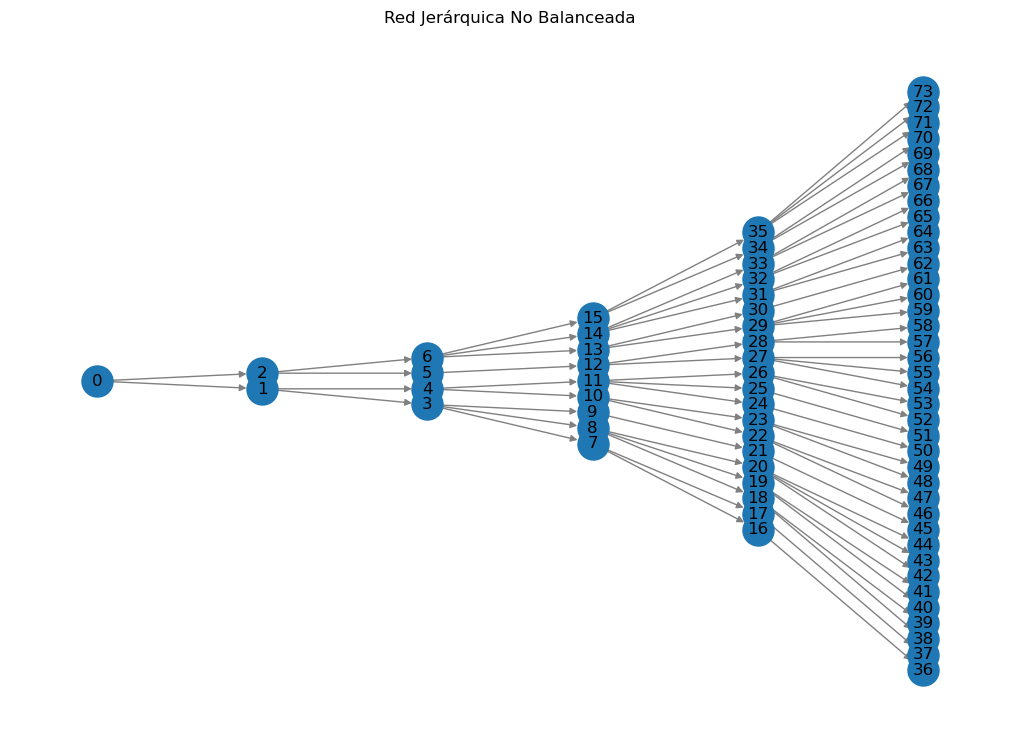

In [11]:
### Red jerárquica

import networkx as nx
import matplotlib.pyplot as plt
import random
# n=0.5levels(max/3)^levels
#children: 2,3,4,5
#levels: 4, 5, 6, 7, 8
def generate_hierarchical_graph(levels, max_children):
    G = nx.DiGraph()
    G.add_node(0, level=0)  # Nodo raíz con nivel 0
    current_node = 1
    prev_level_nodes = [0]

    for level in range(1, levels + 1):
        new_level_nodes = []
        for parent in prev_level_nodes:
            num_children = random.randint(1, max_children)
            for _ in range(num_children):
                G.add_node(current_node, level=level)  # Asignamos nivel
                G.add_edge(parent, current_node)
                new_level_nodes.append(current_node)
                current_node += 1
        prev_level_nodes = new_level_nodes

    return G

# Crear grafo jerárquico
G = generate_hierarchical_graph(levels=5, max_children=3)

# Dibujar la red jerárquica
plt.figure(figsize=(10, 7))

# Usar `level` directamente como clave
pos = nx.multipartite_layout(G, subset_key="level")

nx.draw(G, pos, with_labels=True, node_size=500, edge_color="gray", arrows=True)
plt.title("Red Jerárquica No Balanceada")
plt.show()



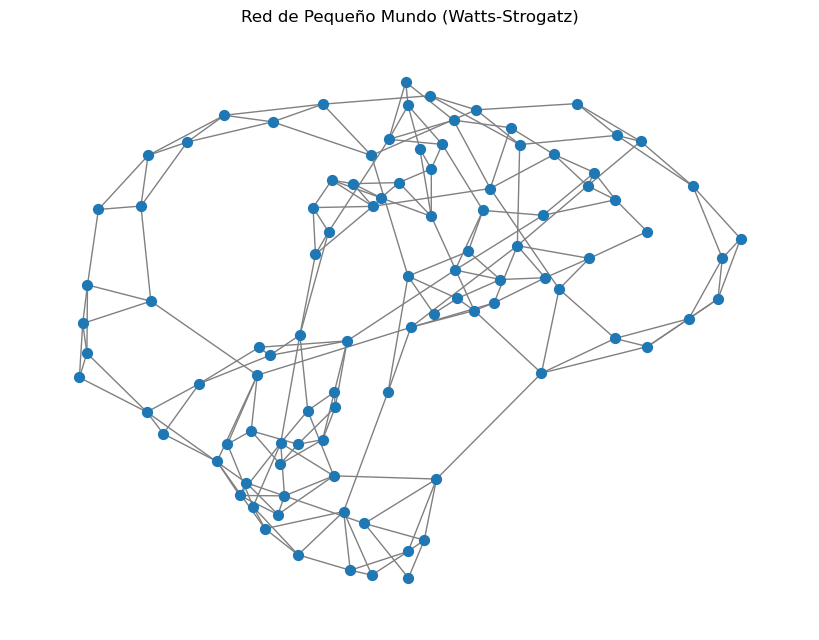

In [15]:
## Red de pequeño mundo
import networkx as nx
import matplotlib.pyplot as plt

# Parámetros del modelo WS
n = 100  # Número de nodos
k = 4    # Cada nodo está conectado a sus k vecinos más cercanos
p = 0.1  # Probabilidad de reorganizar una arista

#combinaciones 5 x 2 x 2
#n. 5 valores distribuidos equitativamente entre el rango de valores del bencharmk
#k max(2, min(5%n, 50)), el otro valor de k: max(4, min(10%n, 100))
# p: 10% y 30%
# Crear la red de pequeño mundo
G = nx.watts_strogatz_graph(n, k, p)

# Dibujar la red
plt.figure(figsize=(8, 6))
nx.draw(G, node_size=50, edge_color="gray", with_labels=False)
plt.title("Red de Pequeño Mundo (Watts-Strogatz)")
plt.show()


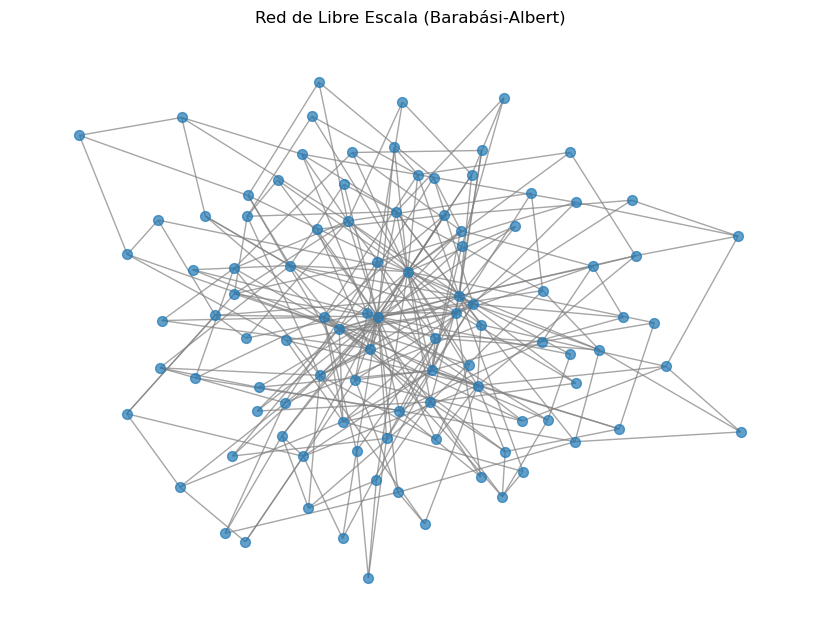

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

# Parámetros de la red BA
n = 100   # Número de nodos
m = 3     # Número de enlaces preferenciales por nuevo nodo

# n 5 valores equitativos entre el rango de las redes del benchamark
# m 4 valores en min(1%n, 10), min(5%n, 50), min(10%n,100), min(20%n,200)
# Generar red Barabási-Albert
G = nx.barabasi_albert_graph(n, m)

# Dibujar la red
plt.figure(figsize=(8, 6))
nx.draw(G, pos=nx.spring_layout(G, seed=42), node_size=50, edge_color="gray", alpha=0.7)
plt.title("Red de Libre Escala (Barabási-Albert)")
plt.show()
